# OLS Baseline Model - Personal Loan Prediction


- **Dataset split**: 80% training, 20% testing
- **Same random seed used across all models** (random_state=42)
- **Model selection**: OLS trained only on training set
- **Final evaluation**: Performed only on test set
- **Classification threshold**: 0.5


In [87]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, mean_squared_error
)
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Load data
df = pd.read_excel("Project Database.xlsx")
df.columns = df.columns.str.strip()

# Define target variable
target = "Personal.Loan"

# Define X and Y
Y = df[target]
X = df.drop(columns=[target, "City"])  # Drop City as instructed

# Convert categorical columns to dummies
X = pd.get_dummies(X, drop_first=True)

# Combine and drop missing values
data = pd.concat([Y, X], axis=1).dropna()

Y = data[target]
X = data.drop(columns=[target])

# Force everything to numeric
X = X.apply(pd.to_numeric, errors="coerce")
Y = pd.to_numeric(Y, errors="coerce")

# Drop rows made missing by coercion
data = pd.concat([Y, X], axis=1).dropna()
Y = data[target]
X = data.drop(columns=[target])

X = X.astype(float)
Y = Y.astype(float)

print("Dataset loaded successfully.")
print(f"Total samples: {len(Y)}")
print(f"Features: {X.shape[1]}")
print(f"Target distribution: {Y.value_counts().to_dict()}")

Dataset loaded successfully.
Total samples: 5000
Features: 12
Target distribution: {0.0: 4520, 1.0: 480}


In [88]:
# Apply 80/20 train/test split with same random seed as other models
X_train, X_test, y_train, y_test = train_test_split(
    X, Y,
    test_size=0.20,
    random_state=42,
    stratify=Y
)


print("TRAIN/TEST SPLIT")

print(f"Training set size: {X_train.shape[0]} samples ({X_train.shape[0]/len(Y)*100:.1f}%)")
print(f"Test set size: {X_test.shape[0]} samples ({X_test.shape[0]/len(Y)*100:.1f}%)")
print(f"\nTraining set class distribution:")
print(f"  Class 0: {sum(y_train == 0)} samples ({sum(y_train==0)/len(y_train)*100:.1f}%)")
print(f"  Class 1: {sum(y_train == 1)} samples ({sum(y_train==1)/len(y_train)*100:.1f}%)")
print(f"\nTest set class distribution:")
print(f"  Class 0: {sum(y_test == 0)} samples ({sum(y_test==0)/len(y_test)*100:.1f}%)")
print(f"  Class 1: {sum(y_test == 1)} samples ({sum(y_test==1)/len(y_test)*100:.1f}%)")

TRAIN/TEST SPLIT
Training set size: 4000 samples (80.0%)
Test set size: 1000 samples (20.0%)

Training set class distribution:
  Class 0: 3616 samples (90.4%)
  Class 1: 384 samples (9.6%)

Test set class distribution:
  Class 0: 904 samples (90.4%)
  Class 1: 96 samples (9.6%)


In [89]:
# Fit OLS model on TRAINING DATA ONLY
X_train_const = sm.add_constant(X_train)

ols_model = sm.OLS(y_train, X_train_const).fit()


print("OLS MODEL - TRAINING SUMMARY")

print(ols_model.summary())

OLS MODEL - TRAINING SUMMARY
                            OLS Regression Results                            
Dep. Variable:          Personal.Loan   R-squared:                       0.357
Model:                            OLS   Adj. R-squared:                  0.355
Method:                 Least Squares   F-statistic:                     184.2
Date:                Sat, 11 Apr 2026   Prob (F-statistic):               0.00
Time:                        23:39:24   Log-Likelihood:                 95.003
No. Observations:                4000   AIC:                            -164.0
Df Residuals:                    3987   BIC:                            -82.18
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------

In [90]:
# Make predictions on TEST SET
X_test_const = sm.add_constant(X_test)
y_pred_proba = ols_model.predict(X_test_const)

# Clip predictions to [0, 1] range
y_pred_proba = np.clip(y_pred_proba, 0, 1)

print("\nPrediction Statistics (Test Set):")
print(f"  Min prediction: {y_pred_proba.min():.6f}")
print(f"  Max prediction: {y_pred_proba.max():.6f}")
print(f"  Mean prediction: {y_pred_proba.mean():.6f}")


Prediction Statistics (Test Set):
  Min prediction: 0.000000
  Max prediction: 0.837127
  Mean prediction: 0.120280


In [91]:
# Convert probabilities to class predictions using threshold = 0.5
threshold = 0.5
y_pred_class = (y_pred_proba > threshold).astype(int)

print(f"\nClassification threshold: {threshold}")
print(f"Predicted class distribution:")
print(f"  Class 0: {sum(y_pred_class == 0)} samples")
print(f"  Class 1: {sum(y_pred_class == 1)} samples")


Classification threshold: 0.5
Predicted class distribution:
  Class 0: 969 samples
  Class 1: 31 samples


In [92]:
# Calculate all performance metrics on TEST SET
test_mse = mean_squared_error(y_test, y_pred_proba)
test_accuracy = accuracy_score(y_test, y_pred_class)
test_precision = precision_score(y_test, y_pred_class, zero_division=0)
test_recall = recall_score(y_test, y_pred_class, zero_division=0)
test_f1 = f1_score(y_test, y_pred_class, zero_division=0)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)
cm = confusion_matrix(y_test, y_pred_class)






print("\nOLS baseline model (Test Set Metrics)")
print(f"Training samples: {len(y_train)}")
print(f"Test samples: {len(y_test)}")
print(f"Number of features: {X_train.shape[1]}")

print("\n TEST SET PERFORMANCE METRICS")

print(f"\nMean Squared Error (MSE):  {test_mse:.6f}")
print(f"Accuracy:                  {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Precision:                 {test_precision:.4f}")
print(f"Recall (Sensitivity):      {test_recall:.4f}")
print(f"F1-Score:                  {test_f1:.4f}")
print(f"ROC AUC:                   {test_roc_auc:.4f}")

print("\n CONFUSION MATRIX (Test Set)")

print("\n                Predicted")
print("              Loan=0  Loan=1")
print(f"Actual Loan=0  {cm[0,0]:>6}  {cm[0,1]:>6}")
print(f"       Loan=1  {cm[1,0]:>6}  {cm[1,1]:>6}")

tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0

print(f"\nInterpretation:")
print(f"  True Negatives (TN - Correct rejections):    {tn}")
print(f"  False Positives (FP - Type I errors):        {fp}")
print(f"  False Negatives (FN - Type II errors):       {fn}")
print(f"  True Positives (TP - Correct approvals):     {tp}")
print(f"  Specificity (TN/(TN+FP)):                    {specificity:.4f}")
print(f"  Sensitivity (TP/(TP+FN)):                    {sensitivity:.4f}")

print("\n")
print(f"R-squared (Training):       {ols_model.rsquared:.6f}")
print(f"Adjusted R-squared:         {ols_model.rsquared_adj:.6f}")



OLS baseline model (Test Set Metrics)
Training samples: 4000
Test samples: 1000
Number of features: 12

 TEST SET PERFORMANCE METRICS

Mean Squared Error (MSE):  0.053912
Accuracy:                  0.9290 (92.90%)
Precision:                 0.9032
Recall (Sensitivity):      0.2917
F1-Score:                  0.4409
ROC AUC:                   0.9425

 CONFUSION MATRIX (Test Set)

                Predicted
              Loan=0  Loan=1
Actual Loan=0     901       3
       Loan=1      68      28

Interpretation:
  True Negatives (TN - Correct rejections):    901
  False Positives (FP - Type I errors):        3
  False Negatives (FN - Type II errors):       68
  True Positives (TP - Correct approvals):     28
  Specificity (TN/(TN+FP)):                    0.9967
  Sensitivity (TP/(TP+FN)):                    0.2917


R-squared (Training):       0.356637
Adjusted R-squared:         0.354700


In [93]:
# Extract and display top coefficients
coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": ols_model.params[1:].values,  # Skip constant
    "Std Error": ols_model.bse[1:].values,
    "T-Statistic": ols_model.tvalues[1:].values,
    "P-Value": ols_model.pvalues[1:].values
})

coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()
coef_df = coef_df.sort_values("Abs_Coefficient", ascending=False)

print("\n" + "="*80)
print("TOP 10 FEATURES")
print("="*80)
print(coef_df.head(10)[['Feature', 'Coefficient']].to_string(index=False))




TOP 10 FEATURES
                Feature  Coefficient
             CD.Account     0.369710
Income / Median in city     0.116363
             Experience     0.076571
                    Age    -0.075832
     Securities.Account    -0.069096
              Education     0.063129
 Median Income Per City     0.050008
             CreditCard    -0.048388
                  CCAvg     0.041620
                 Family     0.033875



Min: 0.0000, Max: 0.8371
Mean: 0.1203, Median: 0.0745
Outside [0,1]: 0 values

Mean pred (Class 0): 0.0893
Mean pred (Class 1): 0.4119


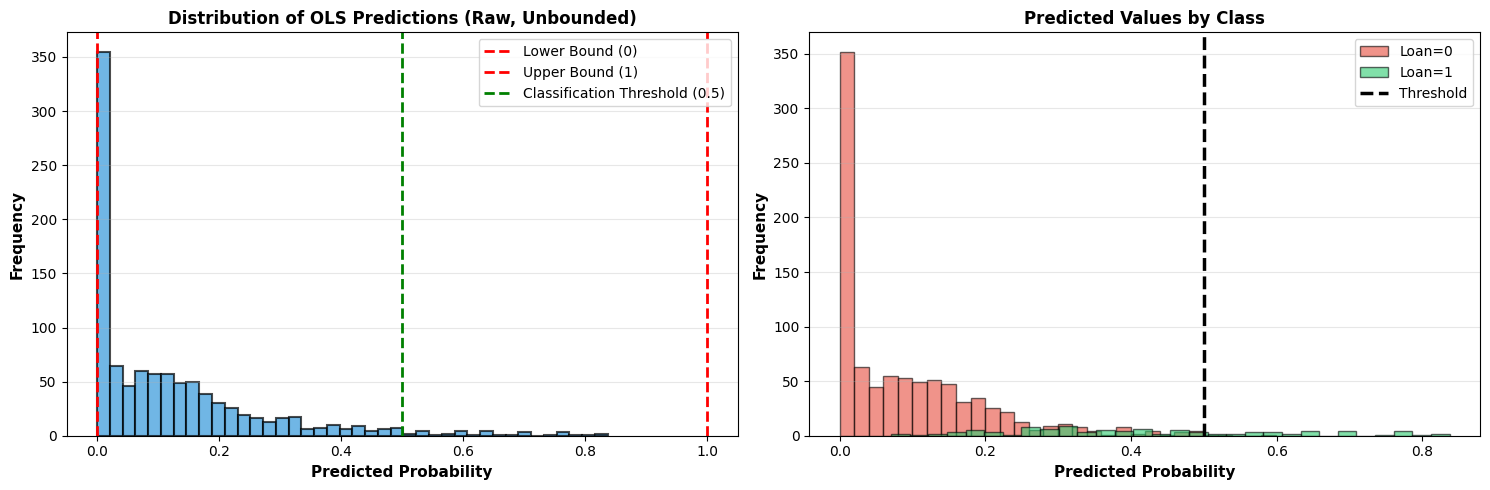

Saved: ols_probability_distribution.png


In [84]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Distribution of raw OLS predictions (unbounded)
ax1 = axes[0]
ax1.hist(y_pred_proba, bins=40, alpha=0.7, color='#3498db', edgecolor='black', linewidth=1.5)
ax1.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Lower Bound (0)')
ax1.axvline(x=1, color='red', linestyle='--', linewidth=2, label='Upper Bound (1)')
ax1.axvline(x=0.5, color='green', linestyle='--', linewidth=2, label='Classification Threshold (0.5)')
ax1.set_xlabel('Predicted Probability', fontweight='bold', fontsize=11)
ax1.set_ylabel('Frequency', fontweight='bold', fontsize=11)
ax1.set_title('Distribution of OLS Predictions (Raw, Unbounded)', fontweight='bold', fontsize=12)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3, axis='y')

print(f"\nMin: {y_pred_proba.min():.4f}, Max: {y_pred_proba.max():.4f}")
print(f"Mean: {y_pred_proba.mean():.4f}, Median: {y_pred_proba.median():.4f}")
print(f"Outside [0,1]: {((y_pred_proba < 0) | (y_pred_proba > 1)).sum()} values")

# Plot 2: Separated distribution by actual class
ax2 = axes[1]
mask_class_0 = y_test == 0
mask_class_1 = y_test == 1

ax2.hist(y_pred_proba[mask_class_0], bins=30, alpha=0.6, label='Loan=0', 
         color='#e74c3c', edgecolor='black', linewidth=1)
ax2.hist(y_pred_proba[mask_class_1], bins=30, alpha=0.6, label='Loan=1', 
         color='#2ecc71', edgecolor='black', linewidth=1)
ax2.axvline(x=0.5, color='black', linestyle='--', linewidth=2.5, label='Threshold')
ax2.set_xlabel('Predicted Probability', fontweight='bold', fontsize=11)
ax2.set_ylabel('Frequency', fontweight='bold', fontsize=11)
ax2.set_title('Predicted Values by Class', fontweight='bold', fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')

print(f"\nMean pred (Class 0): {pred_0_when_actual_0.mean():.4f}")
print(f"Mean pred (Class 1): {pred_1_when_actual_1.mean():.4f}")

plt.tight_layout()
plt.savefig('ols_probability_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved: ols_probability_distribution.png")

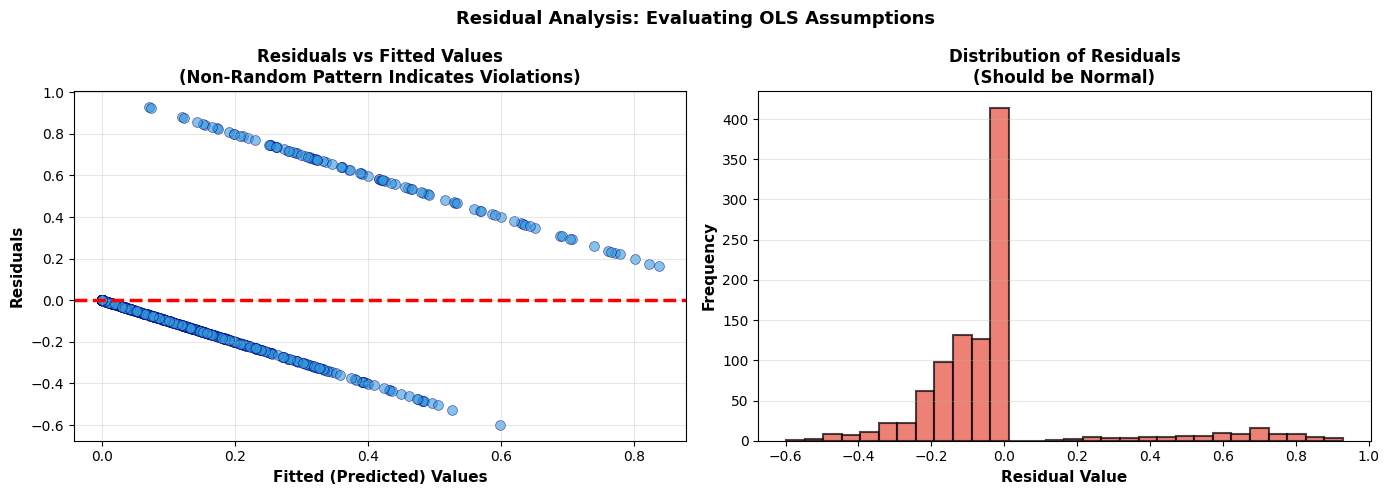

Saved: ols_residual_analysis.png


In [85]:
# Residual Analysis (OLS Assumptions Diagnostic)
print("")

# Calculate residuals
residuals = y_test.values - y_pred_proba
fitted_values = y_pred_proba

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Residuals vs Fitted Values
ax1 = axes[0]
ax1.scatter(fitted_values, residuals, alpha=0.6, s=50, color='#3498db', edgecolor='navy', linewidth=0.5)
ax1.axhline(y=0, color='red', linestyle='--', linewidth=2.5)
ax1.set_xlabel('Fitted (Predicted) Values', fontweight='bold', fontsize=11)
ax1.set_ylabel('Residuals', fontweight='bold', fontsize=11)
ax1.set_title('Residuals vs Fitted Values\n(Non-Random Pattern Indicates Violations)', fontweight='bold', fontsize=12)
ax1.grid(True, alpha=0.3)

# Plot 2: Histogram of Residuals
ax2 = axes[1]
ax2.hist(residuals, bins=30, alpha=0.7, color='#e74c3c', edgecolor='black', linewidth=1.5)
ax2.set_xlabel('Residual Value', fontweight='bold', fontsize=11)
ax2.set_ylabel('Frequency', fontweight='bold', fontsize=11)
ax2.set_title('Distribution of Residuals\n(Should be Normal)', fontweight='bold', fontsize=12)
ax2.grid(True, alpha=0.3, axis='y')

fig.suptitle('Residual Analysis: Evaluating OLS Assumptions', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('ols_residual_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved: ols_residual_analysis.png")


Top 10 Features:
1. CD.Account                     Coef:  0.36971
2. Income / Median in city        Coef:  0.11636
3. Experience                     Coef:  0.07657
4. Age                            Coef: -0.07583
5. Securities.Account             Coef: -0.06910
6. Education                      Coef:  0.06313
7. Median Income Per City         Coef:  0.05001
8. CreditCard                     Coef: -0.04839
9. CCAvg                          Coef:  0.04162
10. Family                         Coef:  0.03388


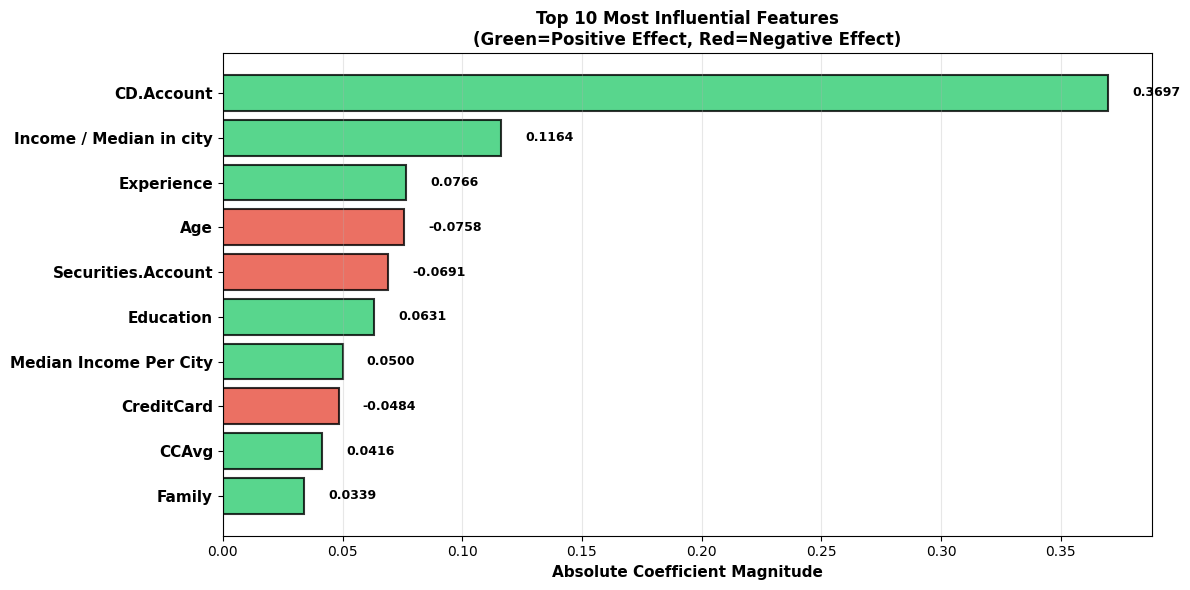

Saved: ols_coefficient_analysis.png


In [86]:
# Coefficient Magnitude: Feature Importance & Interpretability
print("")

# Prepare coefficient dataframe
coef_summary = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': ols_model.params[1:].values,
    'Std Error': ols_model.bse[1:].values,
    'T-Stat': ols_model.tvalues[1:].values,
    'P-Value': ols_model.pvalues[1:].values,
})

coef_summary['Abs_Coef'] = coef_summary['Coefficient'].abs()
coef_summary = coef_summary.sort_values('Abs_Coef', ascending=False)

print("Top 10 Features:")
top_10 = coef_summary.head(10)
for idx, (i, row) in enumerate(top_10.iterrows(), 1):
    print(f"{idx}. {row['Feature']:<30s} Coef: {row['Coefficient']:>8.5f}")

# Visualization: Bar chart of top 10 coefficients
fig, ax = plt.subplots(figsize=(12, 6))

top_features = coef_summary.head(10).sort_values('Abs_Coef')
colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in top_features['Coefficient'].values]

bars = ax.barh(range(len(top_features)), top_features['Abs_Coef'].values, 
                color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)

# Add coefficient values as labels
for i, (idx, row) in enumerate(top_features.iterrows()):
    label = f"{row['Coefficient']:.4f}"
    ax.text(row['Abs_Coef'] + 0.01, i, label, va='center', fontweight='bold', fontsize=9)

ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['Feature'].values, fontweight='bold', fontsize=11)
ax.set_xlabel('Absolute Coefficient Magnitude', fontweight='bold', fontsize=11)
ax.set_title('Top 10 Most Influential Features\n(Green=Positive Effect, Red=Negative Effect)', 
             fontweight='bold', fontsize=12)
ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('ols_coefficient_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved: ols_coefficient_analysis.png")